In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import random
import seaborn as sns
import json
import os
import glob

In [8]:
import plotly.graph_objects as go
import plotly.express as px

In [10]:
names=glob.glob('C:/Users/Admin/Desktop/US/json files/*')

In [12]:
data=pd.DataFrame()
count=0
for name in names:
    year_data=pd.read_json(name)
    count+=year_data.shape[0]
    data=pd.concat([data,year_data],ignore_index=True)

In [14]:
data.drop(columns='sources',inplace=True)

In [16]:
data['total_affected']=data.killed+data.wounded

In [18]:
data['names']=data.names.apply(lambda x : x[0])

In [20]:
data['names']=data.names.str.lower()

In [22]:
regex='yr|yo|child|children|juvenile|ages|age'

In [24]:
juve_data=data[data.names.str.contains(regex)]

In [25]:
juve_data=juve_data.reset_index().drop(columns=['index'])

In [26]:
juve_data.shape

(1294, 7)

In [52]:
#data.to_csv('all_data.csv')

In [50]:
#juve_data.to_csv('all_juve.csv')

In [30]:
cases=data.copy()

In [32]:
cases.head()

,date,killed,wounded,city,state,names,total_affected
0,2019-12-30 00:00:00+00:00,3,1,Baltimore,MD,unknown,4
1,2019-12-29 00:00:00+00:00,0,5,Danville,IL,unknown (victims were all women),5
2,2019-12-29 00:00:00+00:00,1,3,Buffalo,NY,unknown,4
3,2019-12-29 00:00:00+00:00,0,5,Ceres,CA,unknown,5
4,2019-12-27 00:00:00+00:00,0,4,Kennesaw,GA,unkown (victims included 2 juveniles),4


In [12]:
cases['month']=cases.date.dt.month_name().str.slice(stop=3)
cases['year']=cases.date.dt.strftime('%Y')

In [13]:
months=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cases['month']=pd.Categorical(cases['month'],categories=months,ordered=True)

In [14]:
plot_data=cases.groupby(['year','month']).total_affected.sum().reset_index()

In [15]:
plot_data['count']=pd.qcut(plot_data.total_affected,4,labels=['low','moderate','high','concerning'])

In [67]:
plot_data['code']=plot_data['count'].cat.codes

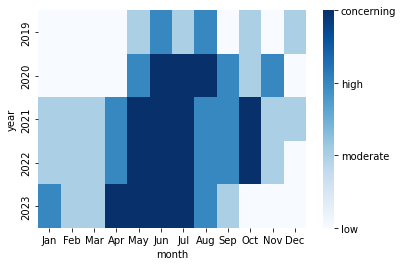

In [68]:
ax=sns.heatmap(plot_data.pivot('year','month','code'),cmap='Blues')
colorbar=ax.collections[0].colorbar
colorbar.set_ticks([0,1,2,3])
colorbar.set_ticklabels(['low','moderate','high','concerning'])
plt.show()

In [69]:
cases['day']=cases.date.dt.day_name().str.slice(stop=3)

In [70]:
days=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
cases['day']=pd.Categorical(cases['day'],categories=days,ordered=True)

In [71]:
plot_data=cases.groupby(['year','day']).total_affected.sum().reset_index()
plot_data['count']=pd.qcut(plot_data.total_affected,4,labels=['low','moderate','high','concerning'])
plot_data['code']=plot_data['count'].cat.codes

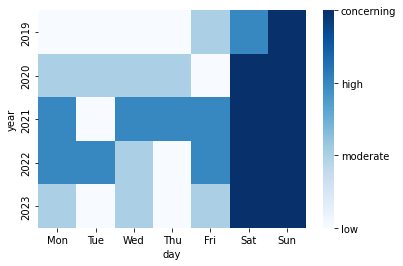

In [72]:
ax=sns.heatmap(plot_data.pivot('year','day','code'),cmap='Blues')
colorbar=ax.collections[0].colorbar
colorbar.set_ticks([0,1,2,3])
colorbar.set_ticklabels(['low','moderate','high','concerning'])
plt.show()

In [73]:
plt_data=cases.groupby('year').total_affected.sum().reset_index()

In [77]:
fig=px.treemap(data,path=[px.Constant('USA'),'state','city'],values='total_affected',color='killed',)

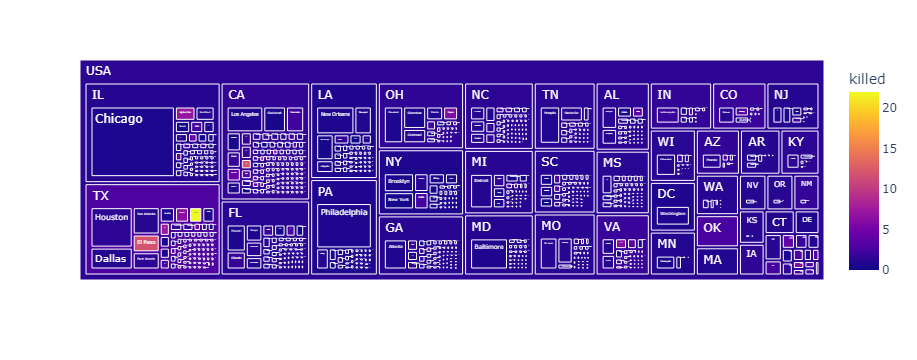

In [78]:
fig.show()